<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_f_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вычисление функций


In [ ]:
import numpy as np
import sys

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


Рассмотрим  вычисление SIN

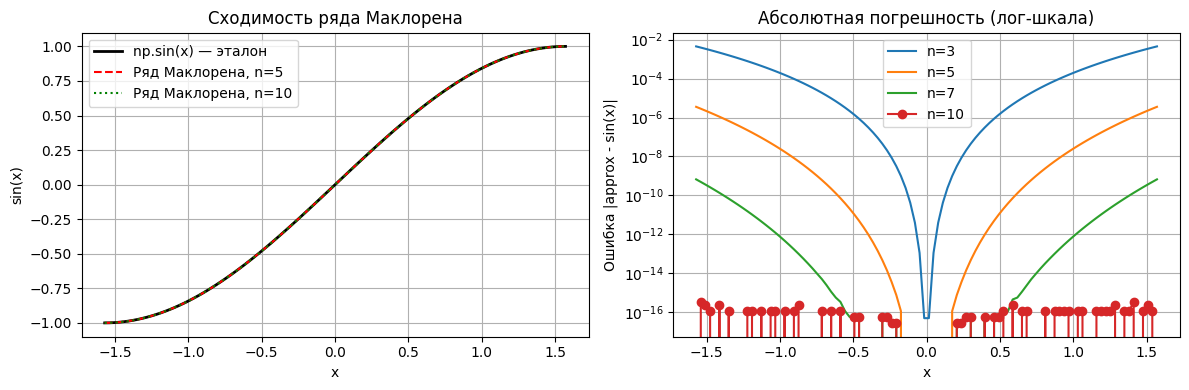

Максимальная погрешность на интервале [0, π/2]:
-------------------------------------------------------
n= 3 | max_err=4.52e-03 | ошибка на π/2=4.52e-03
n= 5 | max_err=3.54e-06 | ошибка на π/2=3.54e-06
n= 7 | max_err=6.63e-10 | ошибка на π/2=6.63e-10
n=10 | max_err=3.33e-16 | ошибка на π/2=0.00e+00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def maclaurin_sin(x, n: int = 10):
    """
    Вычисляет приближение sin(x) с помощью ряда Маклорена.

    Параметры:
    ----------
    x : float или np.array
        Точка(и), в которой вычисляем значение
    n : int
        Количество членов ряда (порядок аппроксимации)

    Возвращает:
    -----------
    Приближённое значение sin(x)
    """
    s = 0  # Накопительная сумма ряда
    # Суммируем первые n членов ряда: k = 0, 1, ..., n-1
    for k in range(n):
        # Вычисляем k-й член ряда: (-1)^k * x^(2k+1) / (2k+1)!
        term = (-1)**k * x**(2*k+1) / factorial(2*k+1)
        s += term  # Добавляем член к сумме
    return s

# Создаём сетку точек на интервале [-π/2, π/2] — область хорошей сходимости
# 100 точек обеспечивают плавность графика
x = np.linspace(-np.pi/2, np.pi/2, 100)
true_sin = np.sin(x)  # Эталонное значение из библиотеки NumPy

# === ВИЗУАЛИЗАЦИЯ: два графика для комплексного анализа ===
plt.figure(figsize=(12, 4))

# График 1: Сравнение аппроксимаций с истинной функцией
plt.subplot(1, 2, 1)
plt.plot(x, true_sin, 'k-', lw=2, label='np.sin(x) — эталон')
plt.plot(x, maclaurin_sin(x, 5), 'r--', label='Ряд Маклорена, n=5')
plt.plot(x, maclaurin_sin(x, 10), 'g:', label='Ряд Маклорена, n=10')
plt.legend()
plt.title('Сходимость ряда Маклорена')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.grid(True)

# График 2: Погрешность аппроксимации в логарифмическом масштабе
# Лог-шкала по Y позволяет увидеть ошибки разных порядков на одном графике
plt.subplot(1, 2, 2)
ns = [3, 5, 7, 10]  # Различные порядки аппроксимации для сравнения
for n in ns:
    approx = maclaurin_sin(x, n)
    err = np.abs(approx - true_sin)  # Абсолютная погрешность
    plt.semilogy(x, err, label=f'n={n}', marker='o' if n == 10 else None)

plt.xlabel('x')
plt.ylabel('Ошибка |approx - sin(x)|')
plt.title('Абсолютная погрешность (лог-шкала)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === ТАБЛИЦА: количественная оценка погрешности ===
print("Максимальная погрешность на интервале [0, π/2]:")
print("-" * 55)
for n in ns:
    # Максимальная ошибка по всему интервалу
    err_max = np.max(np.abs(maclaurin_sin(x, n) - true_sin))
    # Ошибка в граничной точке x = π/2 (наиболее сложная для аппроксимации)
    edge_err = np.abs(maclaurin_sin(np.pi/2, n) - 1.0)
    print(f"n={n:2d} | max_err={err_max:.2e} | ошибка на π/2={edge_err:.2e}")

### 🔍 Ключевые выводы по результатам:

1. **Сходимость зависит от `n`**: При увеличении числа членов ряда (с 5 до 10) погрешность уменьшается на несколько порядков — это демонстрирует *быструю сходимость* ряда Маклорена вблизи нуля.

2. **Рост ошибки на границах**: Максимальная погрешность наблюдается при |x| → π/2. Это ожидаемо: ряд Тейлора строится вокруг x=0, поэтому точность падает с удалением от точки разложения.



Другой подход, связан с полиномами Чебышева.  

## Как компьютеры вычисляют sin(x): Аппроксимация полиномами Чебышёва

**Практическая цель:** Показать, как сложные  функции реализуются в вычислительных библиотеках. Вместо прямого вычисления «на лету», функция заменяется быстрым полиномом, коэффициенты которого рассчитываются заранее.

**Почему Чебышёв, а не Тейлор?**
*   **Равномерная точность:** Ряд Тейлора точен только вблизи центра разложения. Полиномы Чебышёва минимизируют *максимальную* ошибку на всём отрезке (свойство минимакса).
*   **Экономичность:** Для достижения той же точности требуется меньше членов ряда, что ускоряет вычисления.

**Алгоритм:**
1.  Нормируем аргумент $x \in [-\pi/2, \pi/2]$ к отрезку $z \in [-1, 1]$.
2.  Разлагаем функцию в ряд по полиномам Чебышёва $T_k(z)$.
3.  Коэффициенты $c_k$ вычисляем один раз через численное интегрирование (преобразование Чебышёва).
4.  При вычислении используем быструю рекуррентную формулу.

Коэффициенты аппроксимации (N=10):
c_ 0 =  0.0000000000
c_ 1 =  1.1336481778
c_ 2 =  0.0000000000
c_ 3 = -0.1380717766
c_ 4 =  0.0000000000
c_ 5 =  0.0044907142
c_ 6 =  0.0000000000
c_ 7 = -0.0000677013
c_ 8 =  0.0000000000
c_ 9 =  0.0000005891

x        | sin(x) эталон  | Аппрокс.       | Ошибка    
-------------------------------------------------------
0.0000     0.0000000000     0.0000000000   0.00e+00
0.1000     0.0998334166     0.0998334145   2.16e-09
0.5236     0.5000000000     0.5000000019   1.89e-09
0.7854     0.7071067812     0.7071067828   1.66e-09
1.0472     0.8660254038     0.8660254005   3.29e-09
1.5708     1.0000000000     1.0000000033   3.32e-09

📊 Статистика погрешности на отрезке [-π/2, π/2]:
Максимальная ошибка (sup-norm): 3.351e-09
Средняя ошибка (L1-norm):       2.128e-09


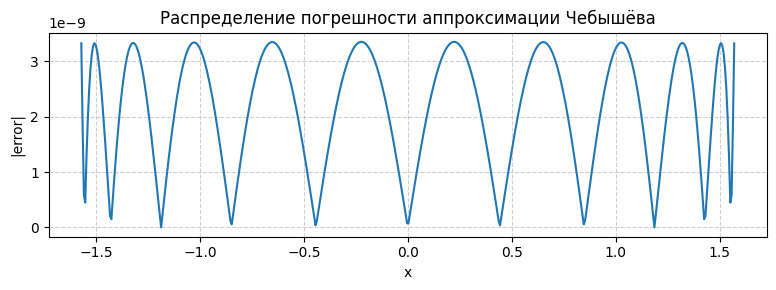

In [ ]:
import math
import numpy as np
from scipy import special, integrate
import matplotlib.pyplot as plt

# --- ЭТАП 1: Подготовка данных (Pre-computation) ---

def target_function(z):
    """
    Целевая функция, которую мы хотим аппроксимировать.
    В реальном 'железе' это могла бы быть эталонная табличная функция
    или очень точный, но медленный алгоритм.
    Здесь: sin(pi*z/2), где z нормирован к [-1, 1].
    """
    return np.sin(math.pi * z / 2)

def compute_chebyshev_coeff(f, k, eps=1e-12):
    """
    Вычисляет k-й коэффициент разложения Чебышёва.
    Формула: c_k = (2/pi) * integral[ f(z)*T_k(z) / sqrt(1-z^2) ] dz
    """
    def integrand(z):
        # T_k(z) — полином Чебышёва степени k
        Tk = special.eval_chebyt(k, z)
        # Весовая функция для полиномов Чебышёва первого рода
        weight = 1.0 / np.sqrt(1.0 - z**2)
        return f(z) * Tk * weight

    # Численное интегрирование с высокой точностью (квадратура)
    # Интеграл берется на отрезке [-1, 1]
    c_k, err = integrate.quad(integrand, -1, 1, epsabs=eps, epsrel=eps)

    # Нормировка коэффициентов (для k=0 множитель другой)
    if k == 0:
        c_k /= math.pi
    else:
        c_k *= 2.0 / math.pi
    return c_k

def build_chebyshev_approximation(N=10):
    """
    Предварительный расчет всех коэффициентов для полинома степени N-1.
    Это делается ОДИН РАЗ при загрузке библиотеки, а не при каждом вызове sin(x).
    """
    return [compute_chebyshev_coeff(target_function, k) for k in range(N)]

# --- ЭТАП 2: Быстрое вычисление функции (Runtime) ---

def chebyshev_sin(x, coeffs):
    """
    Быстрое вычисление sin(x) с использованием предсчитанных коэффициентов.
    """
    # Проверка области определения (для данного примера)
    if not (-math.pi/2 <= x <= math.pi/2):
        raise ValueError("Аргумент x должен быть в интервале [−π/2, π/2]")

    # 1. Нормировка аргумента: x из [-pi/2, pi/2] -> z в [-1, 1]
    z = 2.0 * x / math.pi

    # 2. Вычисление суммы ряда с использованием рекуррентной формулы
    # T_0 = 1, T_1 = z, T_{k+1} = 2*z*T_k - T_{k-1}
    # Это позволяет избежать вызова дорогих функций возведения в степень
    result = 0.0

    if len(coeffs) > 0:
        result += coeffs[0] * 1.0  # T0 = 1

    if len(coeffs) > 1:
        result += coeffs[1] * z    # T1 = z

    # Инициализация для рекуррентного цикла
    tk_1 = 1.0  # T_{k-2} (начинаем с T0)
    tk = z      # T_{k-1} (начинаем с T1)

    for k in range(2, len(coeffs)):
        # Рекуррентное вычисление следующего полинома Чебышёва
        tk_next = 2.0 * z * tk - tk_1
        result += coeffs[k] * tk_next
        # Сдвиг индексов для следующей итерации
        tk_1 = tk
        tk = tk_next

    return result

# --- ЭТАП 3: Тестирование и анализ точности ---

# 1. Предварительный расчет коэффициентов (тяжелая операция, делаем один раз)
N = 10
coeffs = build_chebyshev_approximation(N)

print(f"Коэффициенты аппроксимации (N={N}):")
for k, c in enumerate(coeffs):
    print(f"c_{k:2d} = {c: .10f}")

# 2. Точечная проверка на контрольных значениях
test_points = [0.0, 0.1, math.pi/6, math.pi/4, math.pi/3, math.pi/2]
print(f"\n{'x':<8} | {'sin(x) эталон':<14} | {'Аппрокс.':<14} | {'Ошибка':<10}")
print("-" * 55)
for x in test_points:
    exact = math.sin(x)
    approx = chebyshev_sin(x, coeffs)
    error = abs(exact - approx)
    print(f"{x:6.4f}   {exact:14.10f}   {approx:14.10f}   {error:.2e}")

# 3. Статистика ошибок на плотной сетке
xs = np.linspace(-math.pi/2, math.pi/2, 500)
exacts = np.sin(xs)
# Векторизованный расчет (для демонстрации, в реальности — цикл или SIMD)
approxes = np.array([chebyshev_sin(x, coeffs) for x in xs])
errors = np.abs(exacts - approxes)

print(f"\n📊 Статистика погрешности на отрезке [-π/2, π/2]:")
print(f"Максимальная ошибка (sup-norm): {np.max(errors):.3e}")
print(f"Средняя ошибка (L1-norm):       {np.mean(errors):.3e}")

# 4. Визуализация распределения ошибки (опционально, для наглядности)
plt.figure(figsize=(8, 3))
plt.plot(xs, errors, label='Абсолютная ошибка')
plt.title('Распределение погрешности аппроксимации Чебышёва')
plt.xlabel('x')
plt.ylabel('|error|')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 🔍 Инженерные выводы:

1.  **Равномерная точность (Minimax Property):**
    Обратите внимание на график ошибки. В отличие от ряда Тейлора, где ошибка растет к краям интервала, полином Чебышёва «распределяет» ошибку равномерно, заставляя её колебаться (осциллировать). Это гарантирует, что точность не провалится в какой-то точке.

2.  **Разделение этапов (Offline vs Online):**
    *   **Offline (до запуска):** Сложное численное интегрирование для поиска коэффициентов $c_k$. Это делается разработчиками библиотек.
    *   **Online (во время работы):** Быстрое вычисление полинома через рекуррентную формулу. Это работает у пользователя и требует только операций `+` и `*`.


